In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import time
import os

from gmres_basic import gmres_basic
from gmres_givens import gmres_givens
from gmres_monitor import gmres_monitor

In [2]:
def load_matrix(name, b_name=None):
    A = sio.mmread(f"matrices/{name}").tocsr()
    if b_name:
        b = sio.mmread(f"matrices/{b_name}")
        b = b.toarray().flatten() if hasattr(b, 'toarray') else b.flatten()
    else:
        x_exact = np.ones(A.shape[0])
        b = A.dot(x_exact)
    return A, b

A_small, b_small = load_matrix("cdde6.mtx")
A_large, b_large = load_matrix("parabolic_fem.mtx", "parabolic_fem_b.mtx")

In [3]:
def run_tests(A, b, max_iter=100):
    results = {}
    for name, func in [("Basic", gmres_basic), ("Givens", gmres_givens), ("Monitor", gmres_monitor)]:
        t0 = time.time()
        x, iters, hist = func(A, b, tol=1e-6, max_iter=max_iter)
        t1 = time.time()
        results[name] = {"iters": iters, "hist": hist, "time": t1 - t0}
    return results

res_small = run_tests(A_small, b_small, max_iter=100)
res_large = run_tests(A_large, b_large, max_iter=100)

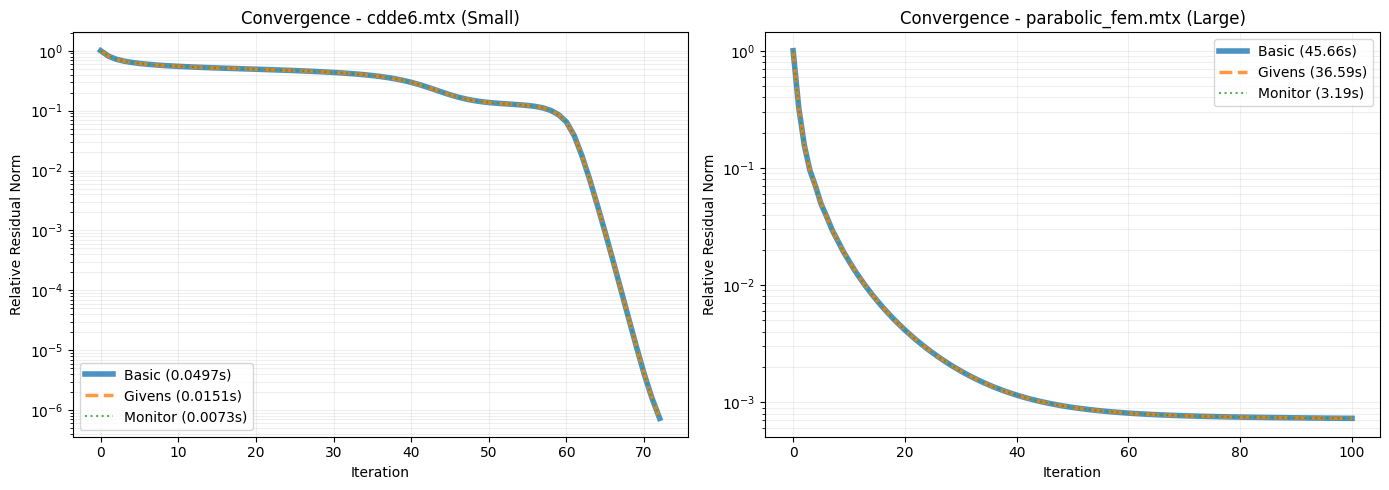

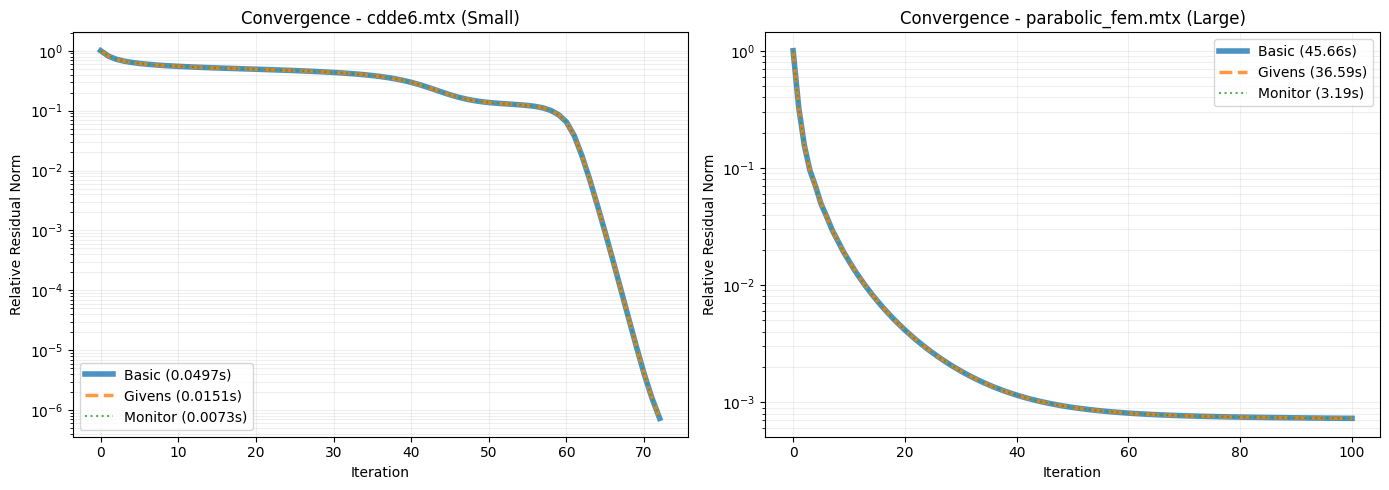

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

linestyles = ['-', '--', ':']
linewidths = [4, 2.5, 1.5]

for i, (name, data) in enumerate(res_small.items()):
    ax1.semilogy(data["hist"], label=f"{name} ({data['time']:.4f}s)", alpha=0.8, linestyle=linestyles[i%3], linewidth=linewidths[i%3])

ax1.set_title("Convergence - cdde6.mtx (Small)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Relative Residual Norm")
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.2)

for i, (name, data) in enumerate(res_large.items()):
    ax2.semilogy(data["hist"], label=f"{name} ({data['time']:.2f}s)", alpha=0.8, linestyle=linestyles[i%3], linewidth=linewidths[i%3])

ax2.set_title("Convergence - parabolic_fem.mtx (Large)")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Relative Residual Norm")
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

fig.tight_layout()
fig.savefig("convergence_plot.pdf", transparent=True, bbox_inches="tight")
fig

In [ ]:
# Bar chart for timing comparison on the large matrix
names = list(res_large.keys())
times = [res_large[n]["time"] for n in names]

fig_time, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

ax.set_title("Execution Time for 100 Iterations (parabolic_fem.mtx)")
ax.set_ylabel("Time (seconds)")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

fig_time.tight_layout()
fig_time.savefig("timing_barchart.pdf", transparent=True, bbox_inches="tight")
fig_time